# Q1 赛季评分热力图

本笔记本仅保留 `plot_season_scores()` 相关绘图流程：读取赛季汇总 CSV，生成一致性与平滑性热力图，并输出到 `outputs/figures/`。


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, Normalize

mpl.rcParams.update({
    # DPI
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # 字体：论文友好（无衬线，审稿安全）
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],

    # 数学符号
    "mathtext.fontset": "stix",

    # 标题与刻度
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


In [2]:
# =========================
# 1) 路径与文件名
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTDIR = os.path.join(BASE_DIR, "figures")
FIGDIR = os.path.join(OUTDIR, "26Feb2-mcm/task1")

INPUT_LONG = os.path.join(DATA_DIR, "26Feb2-mcm", "task2", "inferred_votes_long.csv")
SMOOTH_CSV = os.path.join(DATA_DIR, "26Feb2-mcm", "task1", "q1_smoothness_by_season.csv")

OUT_PNG = os.path.join(FIGDIR, "task1-q1_consistency_with_smoothness.png")

INPUT_LONG, SMOOTH_CSV, OUT_PNG

('/home/winbeau/Tools/jupyter-plot/data/26Feb2-mcm/task2/inferred_votes_long.csv',
 '/home/winbeau/Tools/jupyter-plot/data/26Feb2-mcm/task1/q1_smoothness_by_season.csv',
 '/home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task1/task1-q1_consistency_with_smoothness.png')

In [3]:
# =========================
# 2) 读取 + 赛季汇总
# =========================
ALPHA = 0.5
ACTIVE_EPS = 1e-12
LAMBDA = 0.5
STRICT_SET_MATCH = True

df = pd.read_csv(INPUT_LONG, encoding="utf-8-sig")
smooth_df = pd.read_csv(SMOOTH_CSV, encoding="utf-8-sig")

def active_filter(df_week: pd.DataFrame) -> pd.DataFrame:
    m = (df_week["J_pct"].to_numpy(float) > ACTIVE_EPS) | (df_week["V_hat"].to_numpy(float) > ACTIVE_EPS)
    return df_week.loc[m].copy()


def pick_bottom_k(df_week: pd.DataFrame, score_col: str, k: int) -> list:
    k = int(max(1, k))
    tmp = df_week.sort_values([score_col, "celebrity_name"], ascending=[True, True])
    return tmp["celebrity_name"].head(k).tolist()


def compute_elim_consistency(df_long: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (s, t), sub_all in df_long.groupby(["season", "week"]):
        sub = active_filter(sub_all)
        if sub.empty or len(sub) < 2:
            continue

        actual = sub.loc[sub["is_eliminated_this_week"] == 1, "celebrity_name"].tolist()
        k = len(actual)
        if k <= 0:
            continue

        if "S_hat" not in sub.columns:
            sub["S_hat"] = ALPHA * sub["J_pct"].to_numpy(float) + (1 - ALPHA) * sub["V_hat"].to_numpy(float)

        pred = pick_bottom_k(sub, "S_hat", k)
        ok = int(set(pred) == set(actual)) if STRICT_SET_MATCH else int(set(actual).issubset(set(pred)))
        rows.append({"season": int(s), "elim_consistency": ok})

    elim = pd.DataFrame(rows)
    return elim.groupby("season", as_index=False).agg(elim_consistency=("elim_consistency", "mean"))

elim_df = compute_elim_consistency(df)

season_df = elim_df.merge(
    smooth_df[["season", "smooth_penalty"]],
    on="season",
    how="left",
)

season_df["final_score"] = np.clip(
    season_df["elim_consistency"].to_numpy(float) - LAMBDA * season_df["smooth_penalty"].to_numpy(float),
    0.0,
    1.0,
)
season_df["lambda"] = LAMBDA

season_df.head()

,season,elim_consistency,smooth_penalty,final_score,lambda
0,1,1.0,0.021114,0.989443,0.5
1,2,1.0,0.005796,0.997102,0.5
2,3,1.0,0.008607,0.995696,0.5
3,4,1.0,0.005365,0.997318,0.5
4,5,1.0,0.003803,0.998098,0.5


In [4]:
def plot_season_scores(
    season_df: pd.DataFrame,
    out_png: str,
    title: str | None = None,
    figsize: tuple[float, float] = (14, 3.8),
    cmap: str = "RdBu_r",
) -> str:
    """
    热力图：3 行 × 多赛季列
      行1: elimination consistency L_s
      行2: smoothness penalty P_s (higher = worse)
      行3: final score Score_s = L_s - lambda P_s
    """
    seasons = season_df["season"].astype(int).to_numpy()
    L = season_df["elim_consistency"].to_numpy(float)
    P = season_df["smooth_penalty"].to_numpy(float)
    Score = season_df["final_score"].to_numpy(float)

    # 若 P 有 NaN（没有可比较的相邻周），用 0 填充
    P_filled = np.where(np.isfinite(P), P, 0.0)

    # -------------------------
    # 1) Assemble matrix
    # -------------------------
    M = np.vstack([L, P_filled, Score])
    row_labels = [
        r"$L_s$ (elim. consistency)",
        r"$P_s$ (smooth penalty)",
        r"$Score_s=L_s-\lambda P_s$",
    ]

    if title is None:
        lam = season_df.get("lambda").iloc[0] if "lambda" in season_df.columns else None
        if lam is not None:
            title = f"Q1 Consistency & Smoothness diagnostics (lambda={lam})"
        else:
            title = "Q1 Consistency & Smoothness diagnostics"

    # -------------------------
    # 2) Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)
    base = plt.get_cmap("RdBu_r")
    colors = base(np.linspace(0.2, 0.8, 256))
    soft_RdBu = LinearSegmentedColormap.from_list("soft_RdBu", colors)
    norm = Normalize(vmin=0.0, vmax=1.0)
    im = ax.imshow(M, cmap=soft_RdBu, norm=norm, aspect="auto")
    # im = ax.imshow(M, aspect="auto", cmap=cmap)

    ax.set_yticks(np.arange(3))
    ax.set_yticklabels(row_labels)

    ax.set_xticks(np.arange(len(seasons))[::2])
    ax.set_xticklabels([str(s) for s in seasons[::2]], rotation=0)

    ax.set_xlabel("Season")
    # ax.set_title(title)

    fig.suptitle(title, x=0.5, y=0.95, ha="center", fontsize=20, fontweight="bold")
    
    # -------------------------
    # 3) Colorbar + annotations
    # -------------------------
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Value")

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
    ax.grid(which="minor", axis="y", linewidth=1)
    ax.tick_params(which="minor", left=False)

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    plt.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()
    return out_png

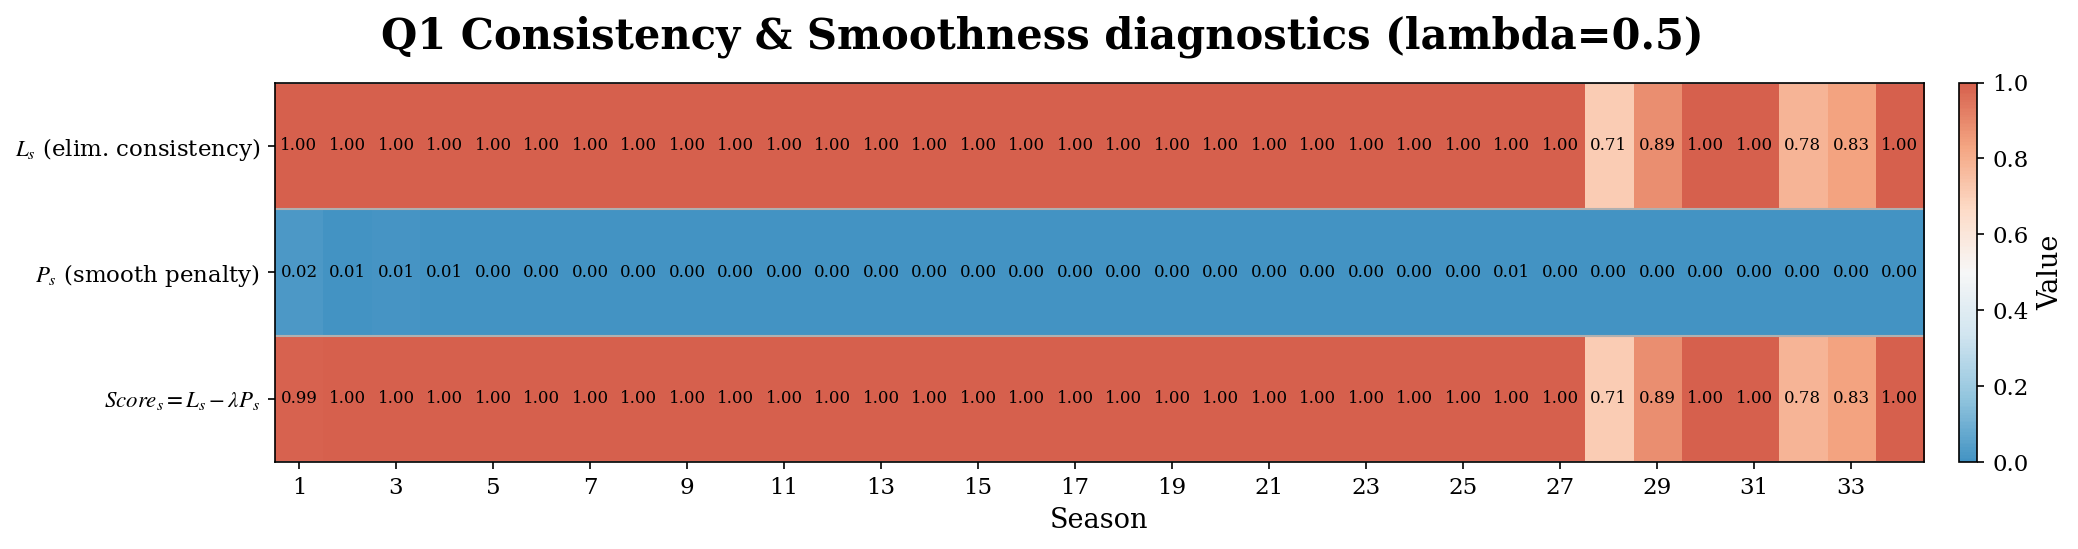

Saved figure: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task1/task1-q1_consistency_with_smoothness.png


In [5]:
fig_path = plot_season_scores(season_df, OUT_PNG)
print("Saved figure:", fig_path)